## 1.Buisness understanding

In this project, I analyze what factors influence developer salaries using the StackOverflow survery dataset.

Questions:
1. What features influence salary the most?
2. Are there surprising patterns in the data?
3. How accurate is the prediction model?
4. What happens in a predicitve scenario?

In [1]:
#imports and setup
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
#load the dataset
df = pd.read_csv('results.csv')
df.head()

C:\Users\Z133423\AppData\Local\Temp\ipykernel_2932\1889522598.py:2: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('results.csv')


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [3]:
#more informations about the file
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), str(119)
memory usage: 64.6 MB


## 2. Data Understanding & Preperation

In this step, I load the dataset, select relevant features, and clean the data.

In [4]:
#just select the needed columns
df = df[["ConvertedCompYearly", "YearsCode","EdLevel", "WorkExp"]]

#rename columns 
df = df.rename(columns={"ConvertedCompYearly": "Salary", "YearsCode": "Experience", "EdLevel":"Education", "WorkExp":"WorkExperience"})

In [5]:
#convert numbers
df["Experience"] = pd.to_numeric(df["Experience"], errors = "coerce")


In [6]:
#make columns out of education
df = pd.get_dummies(df, columns=["Education"], drop_first=True)

In [7]:
#drop null values
df = df.dropna()

## 3. Data Analysis

I explore the relationship between experience and salary using a scatterplot.

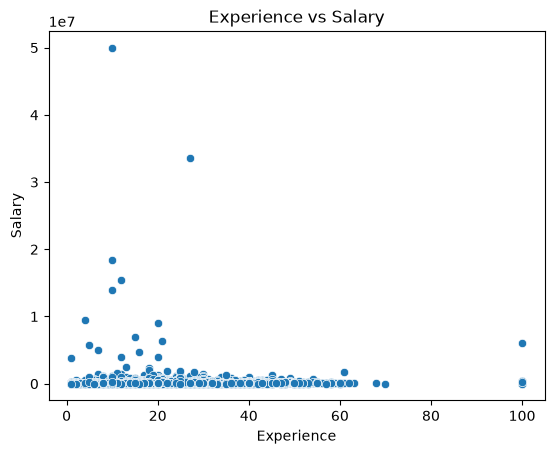

In [8]:
#lets have a first look at the experience to salary plot
sns.scatterplot(x="Experience", y="Salary", data=df)
plt.title("Experience vs Salary")
plt.show()

Outliers with unrealistic salary values were removed to improve analysis and model performance.

In [9]:
#remove outliners
df = df[df["Salary"]<500000] #max 500k salary
df = df[df["Experience"] < 50] #max 50 years experience

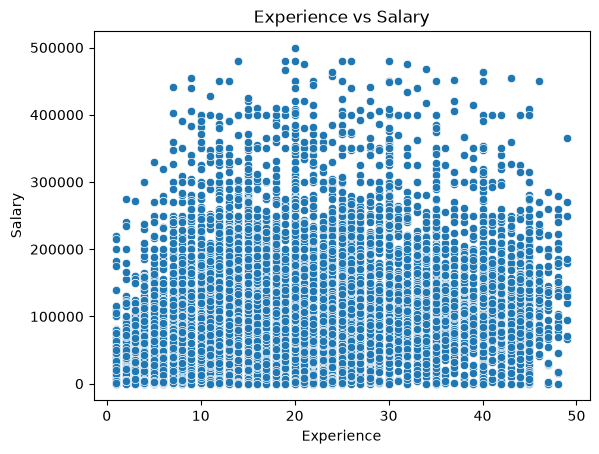

In [10]:
#second look on the salary experience plot
#lets have a first look at the experience to salary plot
sns.scatterplot(x="Experience", y="Salary", data=df)
plt.title("Experience vs Salary")

#save plot for Blog
plt.savefig("salary_plot.png")

#show the plot
plt.show()

The scatterplot shows that salary varies widely across experience levels, indicating that experience alone does not strongly determine salary.

## 4. Modeling
A linear regression model is trained to predict salary based on experience, work experience and education

In [11]:
#Features and targets
X = df.drop("Salary", axis = 1)
y = df["Salary"]

#datasplit
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [12]:
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 1733.7 , 894.06,11665.36,...,10023.81,-9740.24,-2236.48]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Experience','WorkExperience', 'Education_Bachelor’s degree (B.A., B.S., B.Eng., etc.)',..., 'Education_Professional degree (JD, MD, Ph.D, Ed.D, etc.)', 'Education_Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)', 'Education_Some college/university study without earning a degree']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.905e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [13]:
#predictions
y_pred = model.predict(X_test)

## 5.Evaluation
The model performance is evaluated using the R2 score

In [14]:
#Evaluate
score = r2_score(Y_test, y_pred)
print("R2 Score:", score)

R2 Score: 0.1483083469221812


## 6. Prediction scenario
A prediction is madde for a sample developer to demonstrate the model works.

In [15]:
#prediction scenario
sample = X.iloc[0:1]
prediction = model.predict(sample)
print(f"Experience: {X.iloc[0]['Experience']} years")
print("Predicted Salary:", prediction[0])

Experience: 14.0 years
Predicted Salary: 78111.49952356082
